# Otimização de Treliça 2D via Algoritmo Genético

Tradução em Python dos scripts MATLAB da pasta `Truss_GA` (`MAIN_Truss.m`, `DataMEF.m`,
`Truss_MEF.m`, `FitnessFunc.m`, `ConstraintsFunc.m`, `GATruss.m`, `Truss_plot.m`).

Dimensiona as **áreas de seção transversal** das 23 barras de uma treliça plana (13 nós),
minimizando o **peso da estrutura** sujeito a restrições de **tensão admissível** e
**deslocamento máximo**, usando um **Algoritmo Genético (GA)** em vez de um método baseado
em gradiente — apropriado aqui porque a restrição de tensão é descontínua/combinatória em
espírito (dimensionamento discreto de perfis) e o espaço de projeto pode ter múltiplos
ótimos locais.

Como o MATLAB `ga` (Global Optimization Toolbox) não tem equivalente direto no ecossistema
científico Python padrão, a mesma ideia é reproduzida com um **algoritmo genético real
codificado** (seleção por torneio, cruzamento aritmético, mutação gaussiana, elitismo) com
penalização das violações de restrição — a forma como o GA do MATLAB também lida
internamente com restrições não-lineares.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Dados de entrada (`DataMEF.m`)

Coordenadas dos 13 nós, incidência das 23 barras, propriedades do material (aço,
$E=200$ GPa), apoios (nó 1 impedido em $V$; nó 2 engastado), carregamento (cargas verticais
nos nós do banzo superior) e os limites de projeto/restrições do GA: tensão admissível
$T_M=235$ MPa, deslocamento máximo $D_M=1$ mm, peso específico $R_O=77{,}01$ kN/m³.

In [2]:
# coord = [Xno, Yno]
coord = np.array([
    [0.00, 0.00], [6.00, 0.00], [0.00, 0.25], [0.35, 0.25], [0.35, 0.35], [4.50, 0.00],
    [4.50, 1.12], [3.00, 0.00], [3.00, 0.84], [1.50, 0.00], [1.50, 0.56], [0.35, 0.00],
    [6.00, 1.40],
])

# inci = [elemento, prop.mat., prop.geom., nó i, nó j]  (índices de nó em base 1, como no MATLAB)
inci = np.array([
    [1, 1, 1, 1, 12], [2, 1, 1, 12, 10], [3, 1, 1, 10, 8], [4, 1, 1, 8, 6], [5, 1, 1, 6, 2],
    [6, 1, 1, 3, 4], [7, 1, 1, 5, 11], [8, 1, 1, 11, 9], [9, 1, 1, 9, 7], [10, 1, 1, 7, 13],
    [11, 1, 1, 1, 3], [12, 1, 1, 1, 4], [13, 1, 1, 4, 12], [14, 1, 1, 4, 5], [15, 1, 1, 12, 11],
    [16, 1, 1, 11, 10], [17, 1, 1, 10, 9], [18, 1, 1, 8, 9], [19, 1, 1, 8, 7], [20, 1, 1, 7, 6],
    [21, 1, 1, 6, 13], [22, 1, 1, 13, 2], [23, 1, 1, 4, 11],
])

# tmat = [E, Poisson, rho]
tmat = np.array([200e9, 0.3, 0.1])

# cont = [nó, GDL(U=1,V=2)]
cont = np.array([[1, 2], [2, 1], [2, 2]])

# loads = [nó, GDL, valor]
loads = np.array([
    [7, 2, -2e3], [9, 2, -2e3], [11, 2, -2e3], [5, 2, -1.5e3], [13, 2, -1.5e3],
])

nvars = inci.shape[0]

TM = 235e6    # Tensão admissível [Pa]
DM = 1e-3     # Deslocamento máximo [m]
RO = 77.01e3  # Peso específico [N/m^3]

# csle = [cosseno, seno, comprimento] de cada barra
csle = np.zeros((nvars, 3))
for i in range(nvars):
    noi, noj = int(inci[i, 3]) - 1, int(inci[i, 4]) - 1
    dx = coord[noj, 0] - coord[noi, 0]
    dy = coord[noj, 1] - coord[noi, 1]
    Le = np.sqrt(dx * dx + dy * dy)
    csle[i] = [dx / Le, dy / Le, Le]

LB, UB = 1e-4, 13e-4   # limites de área de seção transversal [m^2]

## Análise por elementos finitos (`Truss_MEF.m` / `ConstraintsFunc.m`)

Elemento de barra 2D clássico (método da rigidez direta), idêntico ao usado internamente
por `Truss_MEF.m` e por `ConstraintsFunc.m` (ambos duplicam a mesma montagem no script
original — aqui, uma única função é reaproveitada).

In [3]:
def truss_mef(x):
    """x: vetor de áreas das 23 barras. Retorna (U, Tens)."""
    nnos = coord.shape[0]
    nel = inci.shape[0]
    ngdl = 2

    id_ = np.ones((ngdl, nnos), dtype=int)
    for no, gdl in cont:
        id_[gdl - 1, no - 1] = 0

    neq = 0
    for i in range(nnos):
        for j in range(ngdl):
            if id_[j, i] == 1:
                neq += 1
                id_[j, i] = neq

    F = np.zeros(neq)
    Kg = np.zeros((neq, neq))

    for no, gdl, valor in loads:
        no, gdl = int(no), int(gdl)
        if id_[gdl - 1, no - 1] != 0:
            F[id_[gdl - 1, no - 1] - 1] += valor

    E = tmat[0]
    for i in range(nel):
        noi, noj = int(inci[i, 3]) - 1, int(inci[i, 4]) - 1
        c, s, Le = csle[i]
        ke = (E * x[i] / Le) * np.array([
            [c * c, c * s, -c * c, -c * s],
            [c * s, s * s, -c * s, -s * s],
            [-c * c, -c * s, c * c, c * s],
            [-c * s, -s * s, s * c, s * s],
        ])
        loc = [id_[0, noi], id_[1, noi], id_[0, noj], id_[1, noj]]
        for il in range(4):
            ilg = loc[il]
            if ilg != 0:
                for ic in range(4):
                    icg = loc[ic]
                    if icg != 0:
                        Kg[ilg - 1, icg - 1] += ke[il, ic]

    X = np.linalg.solve(Kg, F)

    U = np.zeros((nnos, 2))
    for i in range(nnos):
        for j in range(2):
            if id_[j, i] != 0:
                U[i, j] = X[id_[j, i] - 1]

    Tens = np.zeros(nel)
    for i in range(nel):
        noi, noj = int(inci[i, 3]) - 1, int(inci[i, 4]) - 1
        vet = np.concatenate([U[noi], U[noj]])
        c, s, Le = csle[i]
        Tens[i] = E / Le * np.array([-c, -s, c, s]) @ vet

    return U, Tens

## Função objetivo e restrições (`FitnessFunc.m`, `ConstraintsFunc.m`)

$$\text{Peso}(x)=\sum_i \rho_{esp}\,L_i\,A_i$$

As restrições são normalizadas e somente a parte que viola o limite (>0) é penalizada:
$$PS=\sum_i \max\!\Big(0,\ \dfrac{\text{Tens}_i}{T_M}-1\Big), \qquad
PD_n=\sum_{gdl}\max\!\Big(0,\ \dfrac{|U_{n,gdl}|}{D_M}-1\Big)$$
$PS$ é um único valor agregando o excesso de tensão em todas as barras; $PD$ é um vetor com
um valor por nó, agregando o excesso de deslocamento nos GDL livres desse nó.

In [4]:
def fitness_func(x):
    """Peso da treliça (função objetivo, a minimizar)."""
    return sum(csle[i, 2] * x[i] * RO for i in range(nvars))


def constraints_func(x):
    """Vetor de restrições c(x); factível quando c(x) <= 0 em todos os componentes."""
    U, Tens = truss_mef(x)
    TS = Tens / TM - 1
    US = np.abs(U) / DM - 1
    PS = np.sum(TS[TS > 0])
    PD = np.sum(np.where(US > 0, US, 0.0), axis=1)
    return np.concatenate([[PS], PD])

## Algoritmo Genético (`GATruss.m`)

GA real codificado com penalização quadrática das violações de restrição
($\text{fitness}_{pen} = \text{Peso} + K\sum \max(0,c)^2$), seleção por torneio, cruzamento
aritmético ("blend crossover") e mutação gaussiana com desvio-padrão decrescente ao longo
das gerações (annealing), preservando o melhor indivíduo a cada geração (elitismo).

In [5]:
def penalized_fitness(x, K=1e5):
    c = constraints_func(x)
    viol = np.sum(np.maximum(0, c) ** 2)
    return fitness_func(x) + K * viol


def ga_truss(pop_size=100, n_gen=200, seed=0):
    rng = np.random.default_rng(seed)
    pop = rng.uniform(LB, UB, size=(pop_size, nvars))

    vet_FO = []    # histórico do melhor valor de função objetivo (penalizada) por geração

    for gen in range(n_gen):
        fits = np.array([penalized_fitness(ind) for ind in pop])
        order = np.argsort(fits)
        pop, fits = pop[order], fits[order]
        vet_FO.append(fits[0])

        elite = pop[:5].copy()
        nova_pop = [elite[0]]
        while len(nova_pop) < pop_size:
            i1, i2 = rng.integers(0, pop_size // 2, 2)
            pai1 = pop[i1] if fits[i1] < fits[i2] else pop[i2]
            i1, i2 = rng.integers(0, pop_size // 2, 2)
            pai2 = pop[i1] if fits[i1] < fits[i2] else pop[i2]

            alpha = rng.uniform(-0.2, 1.2, size=nvars)
            filho = pai1 * alpha + pai2 * (1 - alpha)

            sigma = (UB - LB) * 0.1 * (1 - gen / n_gen)
            filho = filho + rng.normal(0, sigma, size=nvars)
            filho = np.clip(filho, LB, UB)
            nova_pop.append(filho)

        pop = np.array(nova_pop)

    fits = np.array([penalized_fitness(ind) for ind in pop])
    x_best = pop[np.argmin(fits)]

    return x_best, np.array(vet_FO)

## Visualização da treliça (`Truss_plot.m`)

Plota a estrutura indeformada (com apoios) e a estrutura deformada (deslocamentos
amplificados por um fator de escala), com a espessura de cada barra proporcional à sua
área de seção e a barra mais tensionada destacada em vermelho.

In [6]:
def truss_plot(x, U, Tens, fator):
    nnos = coord.shape[0]
    nel = inci.shape[0]

    coordX = coord + fator * U   # coordenadas com fator de escala
    coord_r = coord + U          # coordenadas reais

    imax = np.argmax(Tens)
    nos_apoio = set(cont[:, 0].astype(int) - 1)

    fig, ax = plt.subplots(figsize=(9, 5))
    for i in range(nel):
        noi, noj = int(inci[i, 3]) - 1, int(inci[i, 4]) - 1
        ax.plot(*zip(coord_r[noi], coord_r[noj]), 'o-', color='b')
        mid = (coord[noi] + coord[noj]) / 2
        ax.annotate(str(i + 1), mid, fontsize=7, ha='center',
                    bbox=dict(facecolor=(.9, .9, .9), edgecolor='black'))
    for i in range(nnos):
        ax.annotate(str(i + 1), coord[i], fontsize=10, ha='center', va='bottom')
    for i in nos_apoio:
        ax.scatter(*coord[i], color='k', marker='^', s=140, zorder=5)
    ax.set_title('Treliça indeformada (▲ = apoio)')
    ax.axis('equal')
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 5))
    for i in range(nel):
        noi, noj = int(inci[i, 3]) - 1, int(inci[i, 4]) - 1
        cor = 'r' if i == imax else 'k'
        lw = 4.0 * x[i] / x.max()
        ax.plot(*zip(coordX[noi], coordX[noj]), '-', color=cor, linewidth=lw)
    for i in range(nnos):
        ax.plot(*coordX[i], 'ko')
    for i in nos_apoio:
        ax.scatter(*coord_r[i], color='k', marker='^', s=140, zorder=5)
    ax.set_title(f'Treliça deformada (escala={fator}), barra mais tensionada em vermelho')
    ax.axis('equal')
    plt.show()

## Execução (`MAIN_Truss.m`)

Roda o GA, analisa a treliça ótima por MEF e plota a estrutura deformada com fator de
escala 100 (como no script original).

Tempo de otimização: 57.7 s


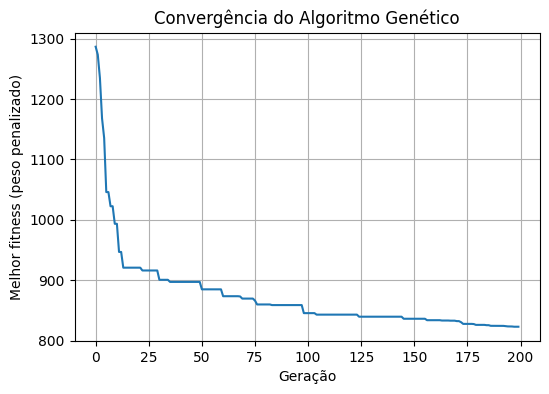

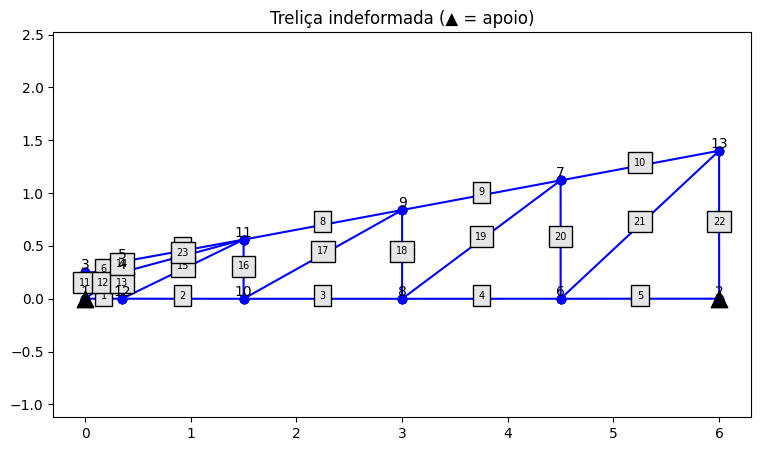

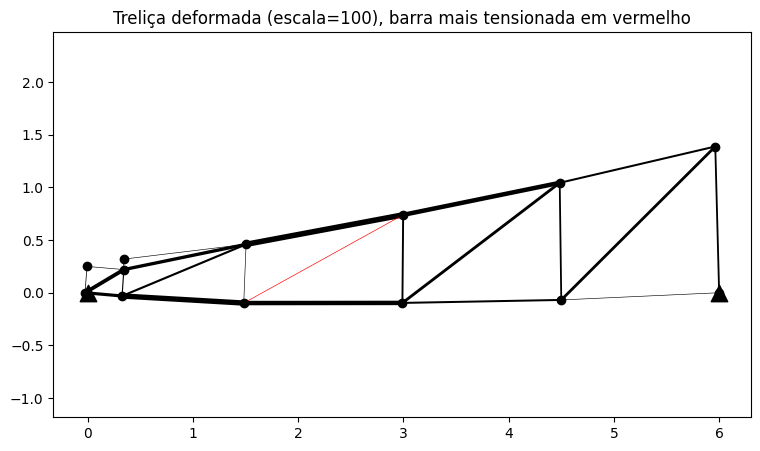

Peso da melhor solução: 822.5045416288958
Restrições (deve ser <= 0): [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.00117203 0.         0.00137232
 0.         0.        ]
Áreas ótimas [m^2]:
[0.00052088 0.00088426 0.00073693 0.00033055 0.00010031 0.00010201
 0.00010022 0.00091537 0.00074033 0.00033303 0.00011989 0.00062719
 0.00018413 0.00013241 0.00035064 0.00010053 0.00010693 0.00031607
 0.0004709  0.00029672 0.00046    0.00030166 0.00054486]


In [7]:
import time

t0 = time.perf_counter()
x_opt, vet_FO = ga_truss(pop_size=100, n_gen=200)
print(f'Tempo de otimização: {time.perf_counter() - t0:.1f} s')

plt.figure(figsize=(6, 4))
plt.plot(vet_FO)
plt.xlabel('Geração')
plt.ylabel('Melhor fitness (peso penalizado)')
plt.title('Convergência do Algoritmo Genético')
plt.grid(True)
plt.show()

fator = 100
U, Tens = truss_mef(x_opt)
truss_plot(x_opt, U, Tens, fator)

print('Peso da melhor solução:', fitness_func(x_opt))
print('Restrições (deve ser <= 0):', constraints_func(x_opt))
print('Áreas ótimas [m^2]:')
print(x_opt)